<a href="https://colab.research.google.com/github/FuscaLuocaG/LUNG-CANCER-ANALYSIS/blob/main/LUNG_CANCER_PROYECT_Project_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LIBRARIES AND FUNCTIONS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import gdown as gd
import pandas as pd
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve)


# 1. Phase 1: Ingestion & Initial Profiling (First Look)



##1.1 Data Loading & Immutability Check

In [ ]:
# Importing dataset

file_id = '1VeLQmvR1vzq2U3z5RIOldcP45Cw_5hSa'
url = f"https://drive.google.com/uc?id={file_id}"

nameframe = "Lung Cancer.csv"

gd.download(url, nameframe, quiet= False)

df_raw = pd.read_csv('Lung Cancer.csv')


Downloading...
From: https://drive.google.com/uc?id=1VeLQmvR1vzq2U3z5RIOldcP45Cw_5hSa
To: /content/Lung Cancer.csv
100%|██████████| 93.4M/93.4M [00:01<00:00, 56.1MB/s]


## 1.2 Data Completeness & Types Audit

In [ ]:
pd.set_option('display.max_rows', 100)

df_raw.head()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


In [ ]:
df_raw.tail()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
889995,889996,40.0,Male,Malta,2022-07-01,Stage IV,No,Passive Smoker,44.8,243,1,1,1,0,Radiation,2023-02-23,0
889996,889997,62.0,Female,Cyprus,2015-09-27,Stage II,Yes,Former Smoker,21.6,240,0,0,0,0,Surgery,2017-06-19,0
889997,889998,48.0,Female,Estonia,2016-03-27,Stage III,Yes,Never Smoked,38.6,242,1,0,0,0,Combined,2017-01-23,1
889998,889999,67.0,Female,Slovakia,2015-12-22,Stage IV,Yes,Former Smoker,18.6,194,1,1,0,0,Chemotherapy,2017-12-12,0
889999,890000,55.0,Female,Malta,2021-07-26,Stage II,Yes,Current Smoker,42.8,250,0,0,0,0,Combined,2022-10-19,0


In [ ]:
df_raw['country'].unique()

array(['Sweden', 'Netherlands', 'Hungary', 'Belgium', 'Luxembourg',
       'Italy', 'Croatia', 'Denmark', 'Malta', 'Germany', 'Poland',
       'Ireland', 'Romania', 'Spain', 'Greece', 'Estonia', 'Cyprus',
       'France', 'Slovenia', 'Latvia', 'Portugal', 'Austria',
       'Czech Republic', 'Finland', 'Lithuania', 'Slovakia', 'Bulgaria'],
      dtype=object)

In [ ]:
df_raw['treatment_type'].unique()

array(['Chemotherapy', 'Surgery', 'Combined', 'Radiation'], dtype=object)

In [ ]:
df_raw['cancer_stage'].unique()

array(['Stage I', 'Stage III', 'Stage IV', 'Stage II'], dtype=object)

In [ ]:
df_raw['smoking_status'].unique()

array(['Passive Smoker', 'Former Smoker', 'Never Smoked',
       'Current Smoker'], dtype=object)

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890000 entries, 0 to 889999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  890000 non-null  int64  
 1   age                 890000 non-null  float64
 2   gender              890000 non-null  object 
 3   country             890000 non-null  object 
 4   diagnosis_date      890000 non-null  object 
 5   cancer_stage        890000 non-null  object 
 6   family_history      890000 non-null  object 
 7   smoking_status      890000 non-null  object 
 8   bmi                 890000 non-null  float64
 9   cholesterol_level   890000 non-null  int64  
 10  hypertension        890000 non-null  int64  
 11  asthma              890000 non-null  int64  
 12  cirrhosis           890000 non-null  int64  
 13  other_cancer        890000 non-null  int64  
 14  treatment_type      890000 non-null  object 
 15  end_treatment_date  890000 non-nul

In [ ]:
df_raw.isnull().sum()

,0
id,0
age,0
gender,0
country,0
diagnosis_date,0
cancer_stage,0
family_history,0
smoking_status,0
bmi,0
cholesterol_level,0


In [ ]:
df_raw.duplicated().sum()

np.int64(0)

## 1.3 Stratetic Feature Selection (Dropping Irrelevant Columns)

In [ ]:
#Dropping ''id'' and ''country'' irrelevant columns for the EDA

df = df_raw.copy()

df.pop('id')
df.pop('country')

,country
0,Sweden
1,Netherlands
2,Hungary
3,Belgium
4,Luxembourg
...,...
889995,Malta
889996,Cyprus
889997,Estonia
889998,Slovakia


 ✂️ Feature Selection & Data Immutability

- **Data Immutability Standard:** `df_raw` is stored intact in memory to prevent redundant disk I/O reloads during pipeline execution.
- **Noise Removal (`id`):** Dropped primary identifier to eliminate false sequential bias in tree-based algorithms.
- **Cardinality Control (`country`):** Dropped high-cardinality nominal attribute prior to encoding. This prevents matrix explosion (*Curse of Dimensionality*) across 890,000 rows and eliminates non-clinical demographic noise.



📊 Dataset Overview & Initial Profiling

- **Dataset Scale:** 890,000 records (High-volume dataset).
- **Data Completeness:** 0 missing values across all columns (`df.isnull().sum() == 0`).
- **Feature Diversity:** Mixed data types including categorical attributes and numerical metrics.

- **Next Steps:** We do the data splits before the EDA
---

#2. Phase 2 : Training-Test Split (Anti Data Leakage Barrier)

## 2.1 Popping out the Target and spliting the data.

In [ ]:
target_name = 'survived'

In [ ]:
X = df.drop(columns = [target_name])

Y = df['survived']

In [ ]:
# Create the function to split the dataset

def create_train_val_test(X, Y, seed = 22):

  #Create the training set 70%, validation 15% and testing 15%

  xtr, x_rest, ytr, y_rest = train_test_split(X, Y, test_size = 0.3, random_state= seed, stratify= Y)

  xvl, xts, yvl, yts = train_test_split(x_rest, y_rest, test_size = 0.5, random_state = seed, stratify = y_rest)

  return xtr, ytr, xvl, yvl, xts, yts

# Execute the function
x_train, y_train, x_val, y_val, x_test, y_test = create_train_val_test(X, Y)

# Verify
print(f'Dimentions of x & y train: {x_train.shape, y_train.shape}')
print(f'Dimentions of x & y val: {x_val.shape, y_val.shape}')
print(f'Dimentions of x & y test: {x_test.shape, y_test.shape}')

Dimentions of x & y train: ((623000, 14), (623000,))
Dimentions of x & y val: ((133500, 14), (133500,))
Dimentions of x & y test: ((133500, 14), (133500,))


## 2.2 Getting X and Y together for the EDA

In [ ]:

df_train = x_train.copy()

df_train[target_name] = y_train


print(f'x_train {type(x_train)}')
print(f'y_train {type(y_train)}')

df_train.head(5)

x_train <class 'pandas.core.frame.DataFrame'>
y_train <class 'pandas.core.series.Series'>


,age,gender,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
839821,35.0,Male,2022-12-08,Stage III,No,Passive Smoker,24.5,162,1,0,1,0,Chemotherapy,2023-08-29,0
315360,59.0,Male,2019-09-28,Stage IV,No,Former Smoker,35.6,265,0,0,0,0,Surgery,2021-03-16,0
555070,33.0,Male,2016-06-15,Stage IV,No,Current Smoker,35.9,242,1,0,0,0,Chemotherapy,2017-03-26,0
224728,59.0,Male,2023-01-20,Stage I,No,Former Smoker,38.1,298,1,1,0,0,Surgery,2024-04-01,1
349925,50.0,Male,2020-01-06,Stage IV,Yes,Current Smoker,25.7,231,1,0,0,1,Chemotherapy,2021-05-31,0


# 3. Phase 3: Exploratory Data Analysis (EDA on Training Data)





## 3.1 Distribution & Synthetic Data Correlation Audit



In [ ]:
# Creating a dataset for the EDA only, and seting up a 20k size sample for speed

df_eda = df_train.copy()
df_eda = df_eda.sample(n = 2000, random_state = 42)


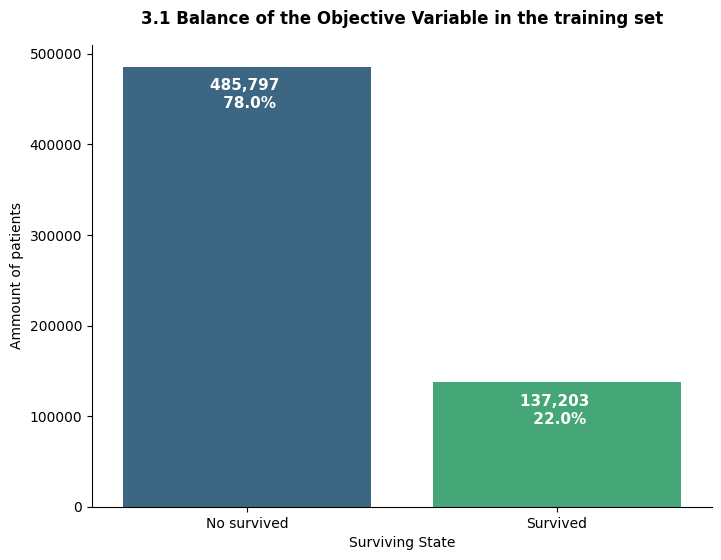

In [ ]:

df_train['survived_label'] = df_train['survived'].map({0: 'No survived', 1: 'Survived'})

plt.figure(figsize = (8, 6))
ax = sns.countplot(data = df_train, x = 'survived_label',hue = 'survived_label', palette = 'viridis', legend = False)

total_patients = len(df_train)

for p in ax.patches:

  counting = int(p.get_height())

  porcentage = (counting / total_patients) * 100

  text = f'{counting:,} \n {porcentage:.1f}%'

  ax.annotate(text, (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center',
  va = 'center', xytext = (0, -20), textcoords = 'offset points', color = "white",
  fontweight = 'bold', fontsize = 11)

plt.title('3.1 Balance of the Objective Variable in the training set', pad = 15, fontweight = 'bold' )
plt.xlabel('Surviving State')
plt.ylabel('Ammount of patients')
sns.despine()

plt.show()


## 3.2 Bivariate Feature Interactions

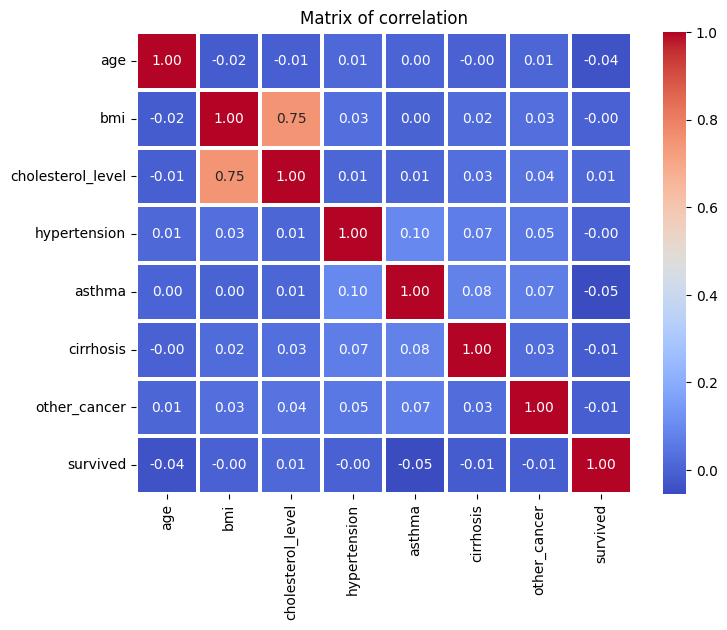

In [ ]:
# Matrix of correlation

df_eda = df_eda.select_dtypes(include= 'number')

correlation_matrix = df_eda.corr(method = 'spearman', numeric_only= True)
plt.figure(figsize = (8, 6))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 1.5)
plt.title('Matrix of correlation')
plt.show()



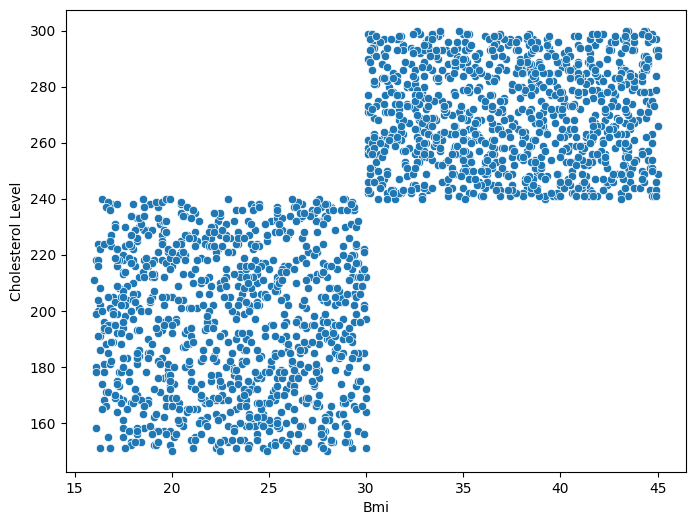

In [ ]:
# Correlation between Body Mass Index and Cholesterol Level

plt.figure(figsize= (8, 6))
sns.scatterplot(x = df_eda['bmi'], y = df_eda['cholesterol_level'])
plt.ylabel('Cholesterol Level')
plt.xlabel('Bmi')
plt.show()

Exploratory Data Analysis (EDA) & Synthetic Data Discovery
- **Target Distribution:** Analyzed the `survived` class balance using percentage-annotated visualizations, verifying the class proportions in `df_train`.
- **Correlation Matrix & Bivariate Analysis:** Computed a Spearman correlation heatmap on a strategic 20k sample to evaluate monotonic relationships among numerical features.
- **Key Discovery (Synthetic Artifacts):** Scatter plots between variables (such as BMI and Cholesterol) revealed uniform rectangular clusters rather than organic clinical distributions, and feature-target correlations hovered near $0.00$.
- **Strategic Pivot:** Concluded that the dataset is artificially generated, shifting the project's focus toward **MLOps, pipeline optimization, and large-scale model benchmarking** rather than clinical inference.

# 4. Phae 4: Preprocessing & Feature Engineering

## 4.1 Ordinal Mapping

MAPPING CANCER STAGE COLUMN

In [ ]:
df['cancer_stage'].unique()

array(['Stage I', 'Stage III', 'Stage IV', 'Stage II'], dtype=object)

In [ ]:
def cancer_mapping(data):

  stage_mapping = {'Stage I': 1, 'Stage II': 2, 'Stage III': 3, 'Stage IV': 4}
  data['cancer_stage_mapped'] = data['cancer_stage'].map(stage_mapping)

  data.drop(columns = ['cancer_stage'], errors = 'ignore', inplace = True)

  return data

x_test = cancer_mapping(x_test)
x_train = cancer_mapping(x_train)
x_val = cancer_mapping(x_val)

x_train.head()

,age,gender,diagnosis_date,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,cancer_stage_mapped
839821,35.0,Male,2022-12-08,No,Passive Smoker,24.5,162,1,0,1,0,Chemotherapy,2023-08-29,3
315360,59.0,Male,2019-09-28,No,Former Smoker,35.6,265,0,0,0,0,Surgery,2021-03-16,4
555070,33.0,Male,2016-06-15,No,Current Smoker,35.9,242,1,0,0,0,Chemotherapy,2017-03-26,4
224728,59.0,Male,2023-01-20,No,Former Smoker,38.1,298,1,1,0,0,Surgery,2024-04-01,1
349925,50.0,Male,2020-01-06,Yes,Current Smoker,25.7,231,1,0,0,1,Chemotherapy,2021-05-31,4


MAPPING SMOKING STATUS COLUMN

In [ ]:
df_train['smoking_status'].unique()

array(['Passive Smoker', 'Former Smoker', 'Current Smoker',
       'Never Smoked'], dtype=object)

In [ ]:
def smoking_status_mapper(data):

  smoking_status_mapped = {"Never Smoked": 1, 'Passive Smoker' : 2, "Former Smoker" : 3, "Current Smoker" : 4}
  data['smoking_status_risk'] = data['smoking_status'].map(smoking_status_mapped)

  data.drop(columns = ['smoking_status'], errors = 'ignore', inplace = True)

  return data

x_train = smoking_status_mapper(x_train)
x_val = smoking_status_mapper(x_val)
x_test = smoking_status_mapper(x_test)

x_train.head()

,age,gender,diagnosis_date,family_history,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,cancer_stage_mapped,smoking_status_risk
839821,35.0,Male,2022-12-08,No,24.5,162,1,0,1,0,Chemotherapy,2023-08-29,3,2
315360,59.0,Male,2019-09-28,No,35.6,265,0,0,0,0,Surgery,2021-03-16,4,3
555070,33.0,Male,2016-06-15,No,35.9,242,1,0,0,0,Chemotherapy,2017-03-26,4,4
224728,59.0,Male,2023-01-20,No,38.1,298,1,1,0,0,Surgery,2024-04-01,1,3
349925,50.0,Male,2020-01-06,Yes,25.7,231,1,0,0,1,Chemotherapy,2021-05-31,4,4


Converting treatment Dates columns (High Cardinality columns) to full period of treatment single column then dropping them before ONE-HOT Encoding.

In [ ]:
def converter_treatment_dates(data):

  data['diagnosis_date'] = pd.to_datetime(data['diagnosis_date'])
  data['end_treatment_date'] = pd.to_datetime(data['end_treatment_date'])

  data['treatment_duration_days'] = (data['end_treatment_date'] - data['diagnosis_date']).dt.days

  data.drop(columns = ['diagnosis_date', 'end_treatment_date'], inplace = True)

  return data

x_train = converter_treatment_dates(x_train)
x_val = converter_treatment_dates(x_val)
x_test = converter_treatment_dates(x_test)

x_train.head()

,age,gender,family_history,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,cancer_stage_mapped,smoking_status_risk,treatment_duration_days
839821,35.0,Male,No,24.5,162,1,0,1,0,Chemotherapy,3,2,264
315360,59.0,Male,No,35.6,265,0,0,0,0,Surgery,4,3,535
555070,33.0,Male,No,35.9,242,1,0,0,0,Chemotherapy,4,4,284
224728,59.0,Male,No,38.1,298,1,1,0,0,Surgery,1,3,437
349925,50.0,Male,Yes,25.7,231,1,0,0,1,Chemotherapy,4,4,511


## 4.2 One-Hot Encoding

In [ ]:
def ohe_and_align(x_train, x_val, x_test):

  categorical_cols = x_train.select_dtypes(include = ['object', 'category']).columns.tolist()

  if len(categorical_cols) > 0:

    x_val = pd.get_dummies(x_val, columns = categorical_cols, drop_first= True, dtype=int)
    x_test = pd.get_dummies(x_test, columns = categorical_cols, drop_first= True, dtype=int)
    x_train = pd.get_dummies(x_train, columns = categorical_cols, drop_first= True, dtype=int)

    val_aligned = x_val.reindex(columns = x_train.columns, fill_value= 0)
    test_aligned = x_test.reindex(columns = x_train.columns, fill_value= 0)

  return x_train, val_aligned, test_aligned

x_train, x_val, x_test = ohe_and_align(x_train, x_val, x_test)

x_train.head()

,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,cancer_stage_mapped,smoking_status_risk,treatment_duration_days,gender_Male,family_history_Yes,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery
839821,35.0,24.5,162,1,0,1,0,3,2,264,1,0,0,0,0
315360,59.0,35.6,265,0,0,0,0,4,3,535,1,0,0,0,1
555070,33.0,35.9,242,1,0,0,0,4,4,284,1,0,0,0,0
224728,59.0,38.1,298,1,1,0,0,1,3,437,1,0,0,0,1
349925,50.0,25.7,231,1,0,0,1,4,4,511,1,1,0,0,0


## 4.3 Feature Scaling (StandardScaler)

In [ ]:
def scale_numerical_features(train_data, val_data, test_data):

  columns_to_scale = ['age', 'bmi', 'cholesterol_level', 'treatment_duration_days']

  scaler = StandardScaler()

  train_data[columns_to_scale] = scaler.fit_transform(train_data[columns_to_scale])

  val_data[columns_to_scale] = scaler.transform(val_data[columns_to_scale])
  test_data[columns_to_scale] = scaler.transform(test_data[columns_to_scale])

  return train_data, val_data, test_data

x_train, x_val, x_test = scale_numerical_features(x_train, x_val, x_test)

x_train.head()

,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,cancer_stage_mapped,smoking_status_risk,treatment_duration_days,gender_Male,family_history_Yes,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery
839821,-2.003309,-0.716383,-1.648215,1,0,1,0,3,2,-1.392110,1,0,0,0,0
315360,0.398426,0.610744,0.722538,0,0,0,0,4,3,0.552434,1,0,0,0,1
555070,-2.203453,0.646612,0.193147,1,0,0,0,4,4,-1.248601,1,0,0,0,0
224728,0.398426,0.909646,1.482100,1,1,0,0,1,3,-0.150759,1,0,0,0,1
349925,-0.502225,-0.572910,-0.060040,1,0,0,1,4,4,0.380223,1,1,0,0,0


# 5. Phase 5: Baseline Modeling & Benchmark.

We are going to choose 2 models for this phase, Logistic Regression and Random Forest.

In [ ]:
log_reg = LogisticRegression(random_state = 42, max_iter = 1000)
rf_cls = RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = -1)

log_reg.fit(x_train, y_train)

rf_cls.fit(x_train, y_train)

y_pred_log_val = log_reg.predict(x_val)
y_proba_log_val = log_reg.predict_proba(x_val)[:, 1]

y_pred_rf_val = rf_cls.predict(x_val)
y_proba_rf_val = rf_cls.predict_proba(x_val)[:, 1]

print('Training Logistic Regression and Random Forest..')


Training Logistic Regression and Random Forest..


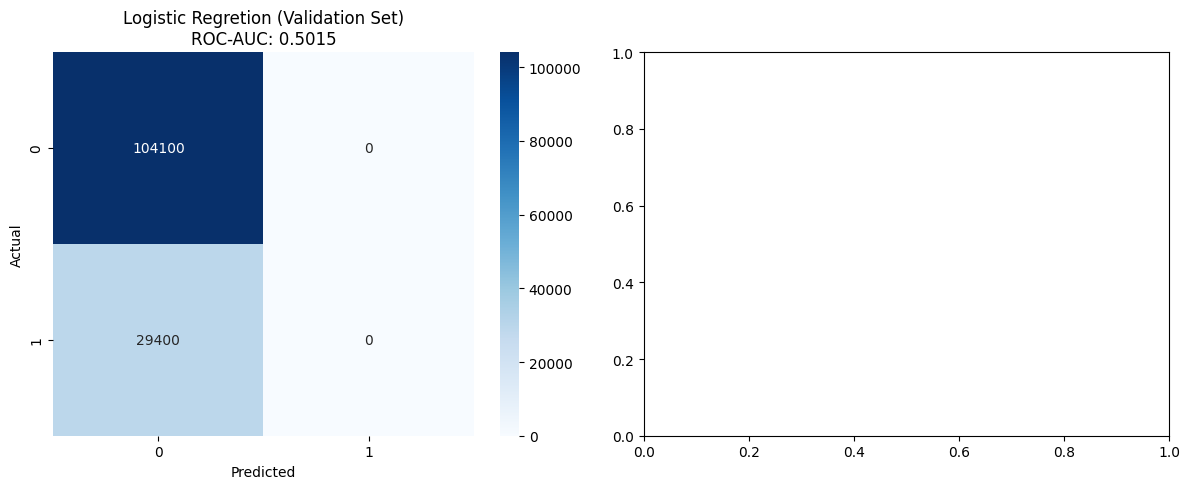

------------------------------------------------------------
      LOGISTIC REGRESSION (VALIDATION SET) REPORT!
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      1.00      0.88    104100
           1       0.00      0.00      0.00     29400

    accuracy                           0.78    133500
   macro avg       0.39      0.50      0.44    133500
weighted avg       0.61      0.78      0.68    133500

------------------------------------------------------------
      RANDOM FOREST (VALIDATION SET) REPORT!
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.78      1.00      0.88    104100
           1       0.23      0.00      0.00     29400

    accuracy                           0.78    133500
   macro avg       0.50      0.50      0.44    133500
weighted avg       0.66      0.78      0.68    133500



In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

sns.heatmap(confusion_matrix (y_val, y_pred_log_val), annot = True, fmt = 'd', cmap ='Blues', ax = axes[0])
axes[0].set_title(f"Logistic Regretion (Validation Set)\nROC-AUC: {roc_auc_score(y_val, y_proba_log_val):.4f}")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print('-' * 60)
print("      LOGISTIC REGRESSION (VALIDATION SET) REPORT!")
print('-' * 60)
print(classification_report(y_val, y_pred_log_val))

print('-' * 60)
print("      RANDOM FOREST (VALIDATION SET) REPORT!")
print('-' * 60)
print(classification_report(y_val, y_pred_rf_val))

